In [1]:
# This notebook demonstrates how to use the pose estimation testing framework

# %% Import libraries
import sys
sys.path.append('..')

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from src.models.mediapipe_model import MediaPipeModel
from src.models.movenet_model import MoveNetModel
from src.analyzers.rep_counter import RepCounter
from src.analyzers.form_analyzer import FormAnalyzer, FaultSeverity

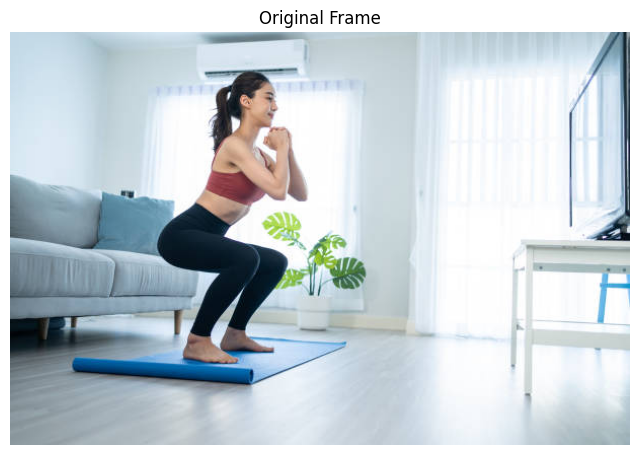

In [2]:
# Load a sample frame (you can extract from video)
test_image_path = "../data/test_frame.jpg"
frame = cv2.imread(test_image_path)
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Display original
plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.title("Original Frame")
plt.axis('off')
plt.show()

Loading MoveNet lightning model...



MoveNet lightning loaded successfully!
Loading MoveNet thunder model...
MoveNet thunder loaded successfully!


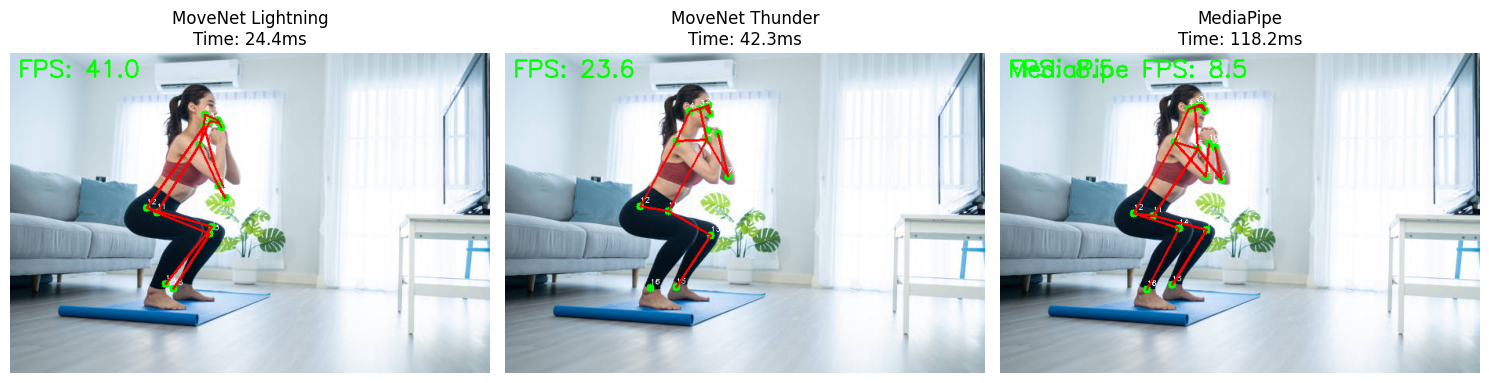

In [3]:
# Initialize models
models = {
    'MoveNet Lightning': MoveNetModel('lightning'),
    'MoveNet Thunder': MoveNetModel('thunder'),
    'MediaPipe': MediaPipeModel()
}

# Process with each model
results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, model) in enumerate(models.items()):
    # Process frame
    result = model.process_frame(frame)
    results[name] = result

    # Visualize
    annotated = model.draw_keypoints(frame, result['keypoints'])
    axes[idx].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f"{name}\nTime: {result['processing_time']*1000:.1f}ms")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Test form analysis
exercise_type = 'squat'
rep_counter = RepCounter(exercise_type)
form_analyzer = FormAnalyzer(exercise_type)

# Simulate processing multiple frames
print(f"Analyzing {exercise_type} form...\n")

for i in range(5):  # Simulate 5 frames
    # Use results from MediaPipe as example
    keypoints = results['MediaPipe']['keypoints'][0]

    # Count reps
    rep_result = rep_counter.process_frame(keypoints, i)

    # Analyze form
    faults = form_analyzer.analyze_form(keypoints, rep_result['current_state'])

    print(f"Frame {i}:")
    print(f"  State: {rep_result['current_state']}")
    print(f"  Primary angle: {rep_result.get('primary_angle', 0):.1f}°")
    print(f"  Faults detected: {len(faults)}")
    for fault in faults:
        print(f"    - {fault.fault_type}: {fault.description}")
    print()

Analyzing squat form...

Frame 0: Transitioning to DOWN (angle: 39.5°)
Frame 0: Starting potential rep
Frame 0:
  State: down
  Primary angle: 39.5°
  Faults detected: 0

Frame 1:
  State: down
  Primary angle: 39.5°
  Faults detected: 0

Frame 2:
  State: down
  Primary angle: 39.5°
  Faults detected: 1
    - knee_cave: Knee tracking issue (Q-angle: 27.1°)

Frame 3:
  State: down
  Primary angle: 39.5°
  Faults detected: 0

Frame 4:
  State: down
  Primary angle: 39.5°
  Faults detected: 0



Performance Comparison:
            Model  Avg Time (ms)  Std Time (ms)       FPS
MoveNet Lightning      17.418218       5.169524 57.411155
  MoveNet Thunder      57.386684      23.654043 17.425645
        MediaPipe      25.553942       1.113220 39.132906


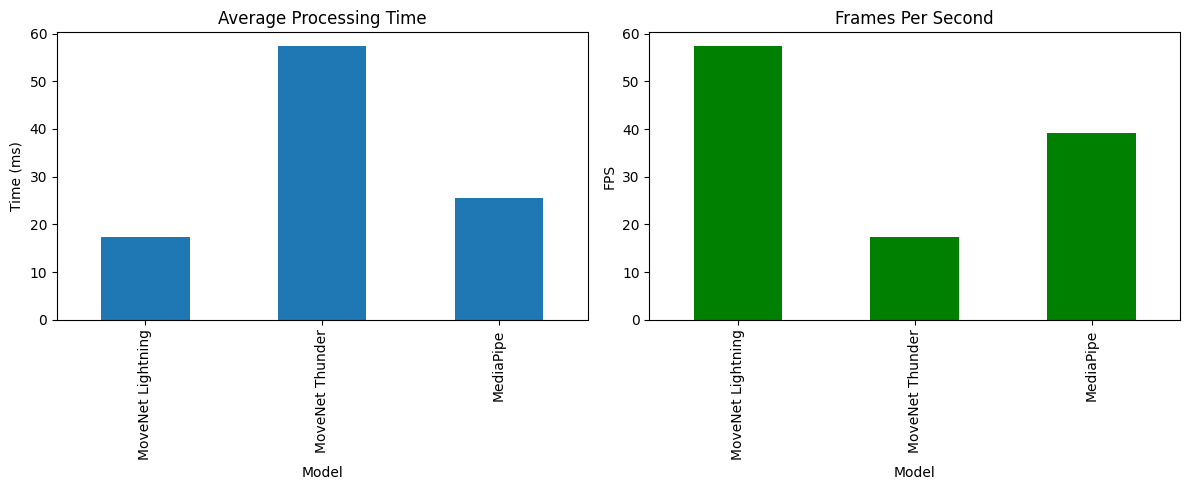

In [5]:
#  Compare processing speeds
performance_data = []

# Test each model on multiple runs
num_runs = 10
for name, model in models.items():
    times = []
    for _ in range(num_runs):
        result = model.process_frame(frame)
        times.append(result['processing_time'])

    performance_data.append({
        'Model': name,
        'Avg Time (ms)': np.mean(times) * 1000,
        'Std Time (ms)': np.std(times) * 1000,
        'FPS': 1.0 / np.mean(times)
    })

# Display results
perf_df = pd.DataFrame(performance_data)
print("Performance Comparison:")
print(perf_df.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Processing time
perf_df.plot(x='Model', y='Avg Time (ms)', kind='bar', ax=ax1, legend=False)
ax1.set_title('Average Processing Time')
ax1.set_ylabel('Time (ms)')

# FPS
perf_df.plot(x='Model', y='FPS', kind='bar', ax=ax2, legend=False, color='green')
ax2.set_title('Frames Per Second')
ax2.set_ylabel('FPS')

plt.tight_layout()
plt.show()

In [6]:
# Process short video clip
video_path = "../data/videos/good_form/squat_good_1.mp4"
output_dir = Path("../data/results/notebook_output")
output_dir.mkdir(parents=True, exist_ok=True)

# Process with all three models
models = {
    'MediaPipe': MediaPipeModel(),
    'MoveNet Lightning': MoveNetModel('lightning'),
    'MoveNet Thunder': MoveNetModel('thunder')
}
print(f"Processing video: {video_path}")

# Process first 100 frames only for demo
max_frames = 100
all_results = {}

for model_name, model in models.items():
    print(f"\nProcessing with {model_name}...")

    cap = cv2.VideoCapture(str(video_path))
    frame_results = []
    frame_count = 0

    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        result = model.process_frame(frame)
        frame_results.append(result)
        frame_count += 1

        if frame_count % 20 == 0:
            print(f"Processed {frame_count} frames...")

    cap.release()
    all_results[model_name] = frame_results
    print(f"Processed {frame_count} frames total with {model_name}")

print(f"\nCompleted processing with all {len(models)} models!")

Loading MoveNet lightning model...
MoveNet lightning loaded successfully!
Loading MoveNet thunder model...
MoveNet thunder loaded successfully!
Processing video: ../data/videos/good_form/squat_good_1.mp4

Processing with MediaPipe...
Processed 20 frames...
Processed 40 frames...
Processed 60 frames...
Processed 80 frames...
Processed 100 frames...
Processed 100 frames total with MediaPipe

Processing with MoveNet Lightning...
Processed 20 frames...
Processed 40 frames...
Processed 60 frames...
Processed 80 frames...
Processed 100 frames...
Processed 100 frames total with MoveNet Lightning

Processing with MoveNet Thunder...
Processed 20 frames...
Processed 40 frames...
Processed 60 frames...
Processed 80 frames...
Processed 100 frames...
Processed 100 frames total with MoveNet Thunder

Completed processing with all 3 models!


Analyzing reps for MediaPipe...
Frame 0: Transitioning to DOWN (angle: 55.0°)
Frame 0: Starting potential rep
Frame 22: Transitioning to UP (angle: 157.0°)
Frame 22: Rep candidate - duration: 22, range: 154.5°
REP 1 COMPLETED! Range: 154.5°, Duration: 22 frames
Frame 49: Transitioning to DOWN (angle: 98.6°)
Frame 49: Starting potential rep
Frame 97: Transitioning to UP (angle: 160.2°)
Frame 97: Rep candidate - duration: 48, range: 153.7°
REP 2 COMPLETED! Range: 153.7°, Duration: 48 frames
Analyzing reps for MoveNet Lightning...
Frame 0: Transitioning to UP (angle: 170.4°)
Analyzing reps for MoveNet Thunder...
Frame 0: Transitioning to UP (angle: 166.3°)


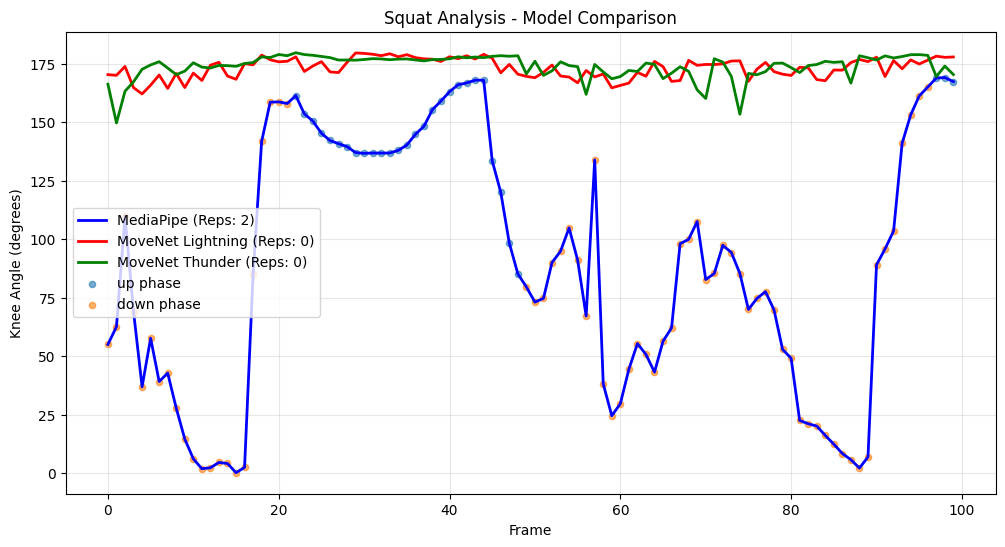


Rep counting results:
MediaPipe: 2 reps detected
MoveNet Lightning: 0 reps detected
MoveNet Thunder: 0 reps detected


In [7]:
# Analyze reps from video
all_rep_analysis = {}

for model_name, frame_results in all_results.items():
    print(f"Analyzing reps for {model_name}...")

    rep_counter = RepCounter('squat')
    rep_data = []

    for i, result in enumerate(frame_results):
        if result['keypoints'].shape[0] > 0:
            keypoints = result['keypoints'][0]  # Just use native format
            rep_result = rep_counter.process_frame(keypoints, i)

            rep_data.append({
                'frame': i,
                'angle': rep_result.get('primary_angle', 0),
                'state': rep_result['current_state'],
                'reps': rep_result['rep_count']
            })

    # Convert to DataFrame for analysis
    rep_df = pd.DataFrame(rep_data)
    all_rep_analysis[model_name] = {
        'data': rep_df,
        'total_reps': rep_counter.rep_count
    }

# Plot angle traces for all models
plt.figure(figsize=(12, 6))
colors = ['blue', 'red', 'green']

for i, (model_name, analysis) in enumerate(all_rep_analysis.items()):
    rep_df = analysis['data']
    if not rep_df.empty:
        plt.plot(rep_df['frame'], rep_df['angle'],
                color=colors[i], linewidth=2,
                label=f'{model_name} (Reps: {analysis["total_reps"]})')

# Mark state changes for first model only (to avoid clutter)
first_model_data = list(all_rep_analysis.values())[0]['data']
if not first_model_data.empty:
    for state in ['up', 'down']:
        state_frames = first_model_data[first_model_data['state'] == state]['frame']
        if len(state_frames) > 0:
            plt.scatter(state_frames, first_model_data.loc[state_frames.index, 'angle'],
                       label=f'{state} phase', alpha=0.6, s=20)

plt.xlabel('Frame')
plt.ylabel('Knee Angle (degrees)')
plt.title('Squat Analysis - Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print summary
print("\nRep counting results:")
for model_name, analysis in all_rep_analysis.items():
    print(f"{model_name}: {analysis['total_reps']} reps detected")

In [8]:
# Get form analysis summary
form_summary = form_analyzer.get_form_summary()

print("Form Analysis Summary:")
print(f"Total faults detected: {form_summary.get('total_faults', 0)}")
print(f"Form score: {form_summary.get('form_score', 100)}/100")

# Check what keys are available in form_summary
print(f"\nAvailable keys in form_summary: {list(form_summary.keys())}")

# Safely handle fault breakdown
if 'fault_counts' in form_summary:
    print("\nFault breakdown:")
    for fault_type, count in form_summary['fault_counts'].items():
        print(f"  {fault_type}: {count} occurrences")
else:
    print("\nFault breakdown: No fault_counts data available")

# Safely handle recommendations
if 'recommendations' in form_summary:
    print("\nRecommendations:")
    for rec in form_summary['recommendations']:
        print(f"  • {rec}")
else:
    print("\nRecommendations: No recommendations available")

# Print all available data
print(f"\nFull form_summary content:")
for key, value in form_summary.items():
    print(f"  {key}: {value}")

Form Analysis Summary:
Total faults detected: 1
Form score: 89.9/100

Available keys in form_summary: ['total_faults', 'unique_fault_types', 'fault_counts', 'severity_breakdown', 'form_score', 'consistency_score', 'session_quality', 'recommendations', 'fault_timeline', 'summary_stats']

Fault breakdown:
  knee_cave: 1 occurrences

Recommendations:
  • {'priority': 3, 'fault_type': 'knee_cave', 'description': 'Knee tracking issue (Q-angle: 27.1°)', 'correction': 'Focus on external rotation and glute activation', 'frequency': 1, 'severity': 'severe'}

Full form_summary content:
  total_faults: 1
  unique_fault_types: 1
  fault_counts: {'knee_cave': 1}
  severity_breakdown: {'minor': 0, 'moderate': 0, 'severe': 1}
  form_score: 89.9
  consistency_score: 50.0
  session_quality: good
  recommendations: [{'priority': 3, 'fault_type': 'knee_cave', 'description': 'Knee tracking issue (Q-angle: 27.1°)', 'correction': 'Focus on external rotation and glute activation', 'frequency': 1, 'severity':